In [2]:
# Use this in Colab session
#%cd /content
#!rm -rf rainfall_kf
#
#!git clone https://github.com/Felix-Schwer/rainfall_kf.git
#%cd rainfall_kf

# Use this on local machine
%cd C:/Users/fschwer/Documents/CEE 261D Data Assimilation/Final Project/rainfall_kf

!pip install -e .

C:\Users\fschwer\Documents\CEE 261D Data Assimilation\Final Project\rainfall_kf
Obtaining file:///C:/Users/fschwer/Documents/CEE%20261D%20Data%20Assimilation/Final%20Project/rainfall_kf
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for rainfall_kf (pyproject.toml): started
  Building editable for rainfall_kf (pyproject.toml): finished with status 'done'
  Created wheel for rainfall_kf: filename=rainfall_kf-0.1.0-0.editable-py3-none-any.whl size=2787 sha256=010c295969ca20a2ce8810d1b122dad555ef24e92f80a1d2df77f0a57e00f71b
  St

In [3]:
import xarray as xr
import pandas as pd
import numpy as np

# have to cd on local machine
%cd C:/Users/fschwer/Documents/CEE 261D Data Assimilation/Final Project/rainfall_kf/notebooks

prism_ds = xr.open_dataset('../data/prism_basin_means.nc')
gpm_ds = xr.open_dataset('../data/gpm_basin_means.nc')
et_ds = xr.open_dataset('../data/et_basin_means.nc')
temp_ds = xr.open_dataset('../data/temp_basin_means.nc')

from rainfall_kf.models.hbvedu import processed_inputs_fromds
et_ds, (monthly_et, monthly_temp) = processed_inputs_fromds(et_ds, temp_ds, starttime='2000-01-01', endtime='2020-12-31')


C:\Users\fschwer\Documents\CEE 261D Data Assimilation\Final Project\rainfall_kf\notebooks


In [4]:
stations_in_basin = {
    "18040001": ["11273400"], # Middle San Joaquin-Lower Chowchilla
    "18040002": ["11274550"], # Lower San Joaquin River
    "18040003": ["11303500"], # San Joaquin Delta
    "18040006": [], # Upper San Joaquin
    "18040007": [], # Fresno River
    "18040008": ["11272500"],# Upper Merced
    "18040009": ["11290000"], # Upper Tuolumne
    "18040010": ["11303000"], # Upper Stanislaus
    "18040011": [], # Upper Calaveras
    "18040012": ["11325500"], # Upper Mokelumne
    "18040013": [], # Upper Cosumnes
    "18040014": ["11255575"] # Panoche-San Luis Reservoir
}

stream_ds = xr.open_dataset('../data/streamflow.nc')

In [22]:
basin_id = "18040009"
station_id = stations_in_basin[basin_id][0]
start_time = stream_ds.sel(site=station_id).continuous_start
end_time = stream_ds.sel(site=station_id).continuous_end

In [23]:
inputs = np.array([
    temp_ds.tmean.sel(basin=basin_id, time=slice(start_time, end_time)).values,
    gpm_ds.precipitation.sel(basin=basin_id, time=slice(start_time, end_time)).values,
    monthly_temp.sel(basin=basin_id, time=slice(start_time, end_time)).values,
    monthly_et.sel(basin=basin_id, time=slice(start_time, end_time)).values
])

In [24]:
times = stream_ds.streamflow.sel(site=station_id, time=slice(start_time, end_time)).time.values
observations_imperial = np.array([stream_ds.streamflow.sel(site=station_id, time=slice(start_time, end_time)).values])
cfs_to_m3s = 0.0283168
sqmi_to_km2 = 2.58999
basin_area_km2 = stream_ds.sel(site=station_id).drainage_area.values * sqmi_to_km2
observations = observations_imperial * cfs_to_m3s / basin_area_km2 # m3/s/km2
observations = observations * 86400 / 1000000 * 1000 # m/day

In [25]:
from rainfall_kf.models.hbv2 import SJV_Sierra_UBParameters, SJV_Sierra_LBParameters, SJV_Valley_UBParameters, SJV_Valley_LBParameters

Valley_Params = 0.5*(SJV_Valley_UBParameters + SJV_Valley_LBParameters)
Sierra_Params = 0.5*(SJV_Sierra_UBParameters + SJV_Sierra_LBParameters)
#ALPHA = 0.67 # Adjust on Watershed Geography/Characteristics (=1 Sierras, =0 Valley Floor)
#Params = ALPHA * Sierra_Params + (1 - ALPHA) * Valley_Params

In [26]:
N_STATES = 5
N_OBS = 1
N_ENS = 100

Qassumed = np.diag([2, 2, 0.5, 0.5, 1e-40])**2
Rassumed = np.diag([0.5])**2

x0 = np.array([[0., 100., 10., 10., 10.]]).T # initial state guess

initial_ensemble = x0 + np.linalg.cholesky(Qassumed).T @ np.random.randn(N_STATES, N_ENS)

In [ ]:
from rainfall_kf.enkf import EnsembleKalmanFilter
from rainfall_kf.models.hbvedu import HBVTransition, HBVObservation

results = []

alphas = np.linspace(0., 1., 21)
for alpha in alphas:
    Params = alpha * Valley_Params + (1 - alpha) * Sierra_Params

    enkf = EnsembleKalmanFilter(
        TransitionEquation=lambda states, inputs: HBVTransition(states, inputs, Params),
        ObservationEquation=lambda states: HBVObservation(states, Params),
        Q=Qassumed,
        R=Rassumed,
        addGaussInputSig=np.array([0.2, 0., 0., 0.]),
        mulLognormInputSig=np.array([0., 0.2, 0., 0.]),
        gain_method='pinv' #pinv or analytic
    )

    result = enkf.run(initial_ensemble=initial_ensemble, times=times, inputs=inputs, observations=observations)
    results.append(result)

Text(0.21000000000000002, 0.5, 'alpha = 0.20')

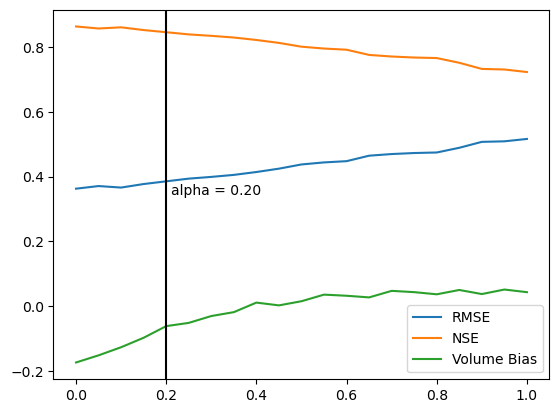

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(alphas, [result.RMSE for result in results], label='RMSE')
ax.plot(alphas, [result.NSE for result in results], label='NSE')
ax.plot(alphas, [result.VolBias for result in results], label='Volume Bias')
ax.legend()
ind = 10
ax.axvline(alphas[ind], color='k')
ax.text(alphas[ind]+0.01, 0.5, f'alpha = {alphas[ind]:.2f}', transform=ax.get_xaxis_transform())

In [38]:
from rainfall_kf.enkf import EnsembleKalmanFilter
from rainfall_kf.models.hbvedu import HBVTransition, HBVObservation

results = []

alphas = np.linspace(0., 1., 21)
for alpha in alphas:
    Params = alpha * SJV_Valley_UBParameters + (1 - alpha) * SJV_Valley_LBParameters

    enkf = EnsembleKalmanFilter(
        TransitionEquation=lambda states, inputs: HBVTransition(states, inputs, Params),
        ObservationEquation=lambda states: HBVObservation(states, Params),
        Q=Qassumed,
        R=Rassumed,
        addGaussInputSig=np.array([0.2, 0., 0., 0.]),
        mulLognormInputSig=np.array([0., 0.2, 0., 0.]),
        gain_method='pinv' #pinv or analytic
    )

    result = enkf.run(initial_ensemble=initial_ensemble, times=times, inputs=inputs, observations=observations)
    results.append(result)

Text(0.21000000000000002, 0.5, 'alpha = 0.20')

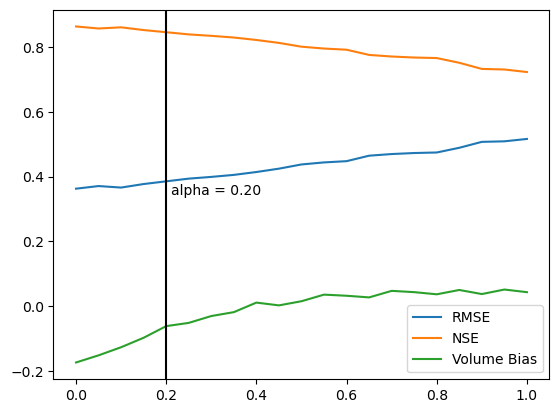

In [42]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(alphas, [result.RMSE for result in results], label='RMSE')
ax.plot(alphas, [result.NSE for result in results], label='NSE')
ax.plot(alphas, [result.VolBias for result in results], label='Volume Bias')
ax.legend()
ind = 4
ax.axvline(alphas[ind], color='k')
ax.text(alphas[ind]+0.01, 0.5, f'alpha = {alphas[ind]:.2f}', transform=ax.get_xaxis_transform())

In [43]:
Params = 0.2 * SJV_Valley_UBParameters + (1 - 0.2) * SJV_Valley_LBParameters

enkf = EnsembleKalmanFilter(
    TransitionEquation=lambda states, inputs: HBVTransition(states, inputs, Params),
    ObservationEquation=lambda states: HBVObservation(states, Params),
    Q=Qassumed,
    R=Rassumed,
    addGaussInputSig=np.array([0.2, 0., 0., 0.]),
    mulLognormInputSig=np.array([0., 0.2, 0., 0.]),
    gain_method='analytic' #pinv or analytic
)

result = enkf.run(initial_ensemble=initial_ensemble, times=times, inputs=inputs, observations=observations)

In [44]:
Params

HBVParameters(d=2.2, fc=320.0, beta=4.2, c=0.030000000000000002, k0=0.08000000000000002, l=4.4, k1=0.032, k2=0.0048000000000000004, kp=0.018000000000000002, pwp=200.0, tt=-0.4)

Text(0.5, 0, 'Lags')

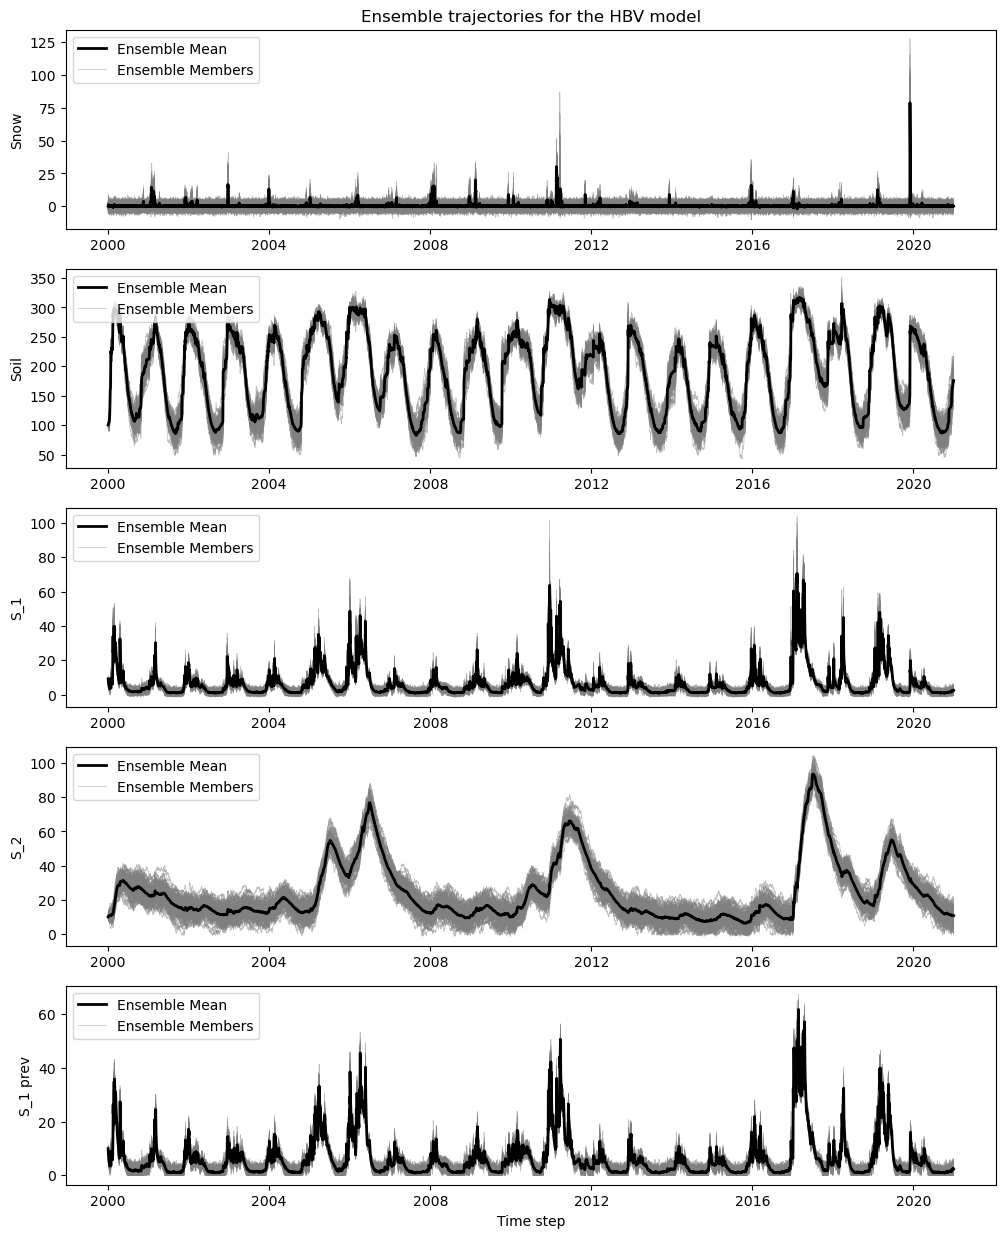

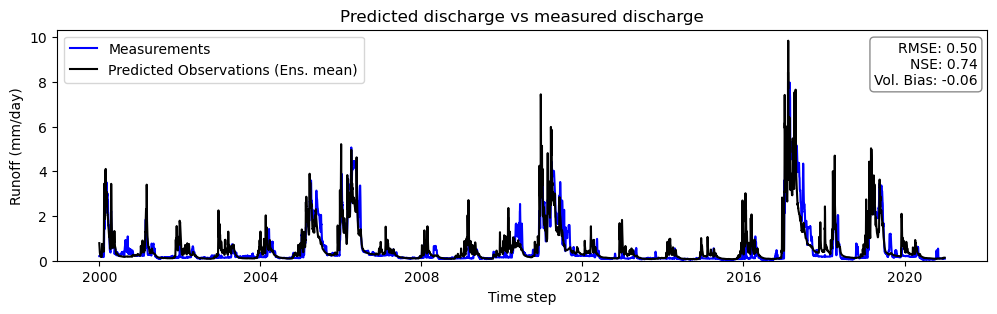

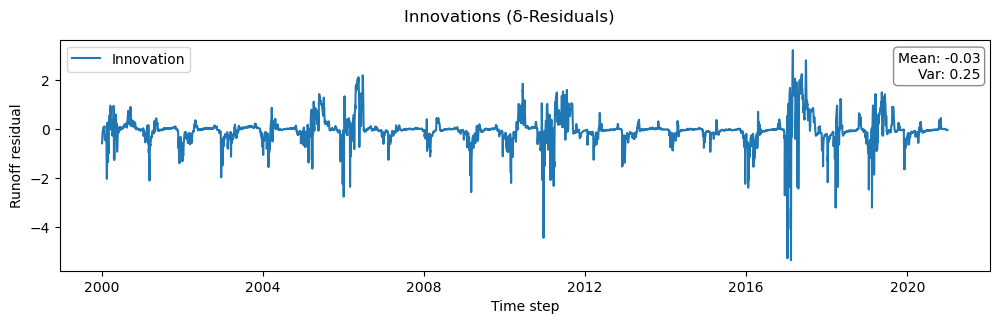

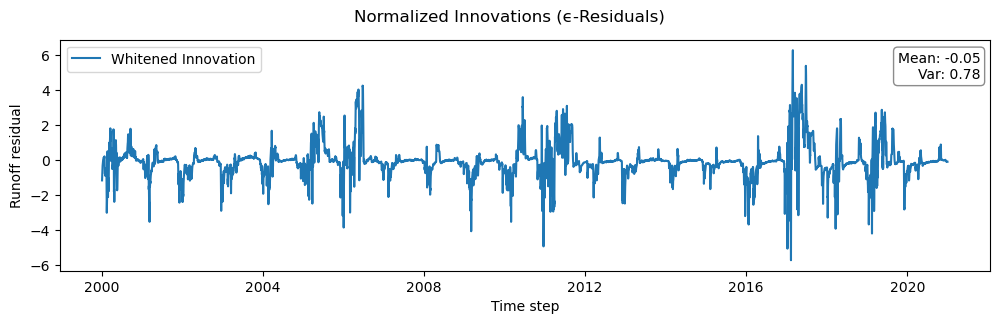

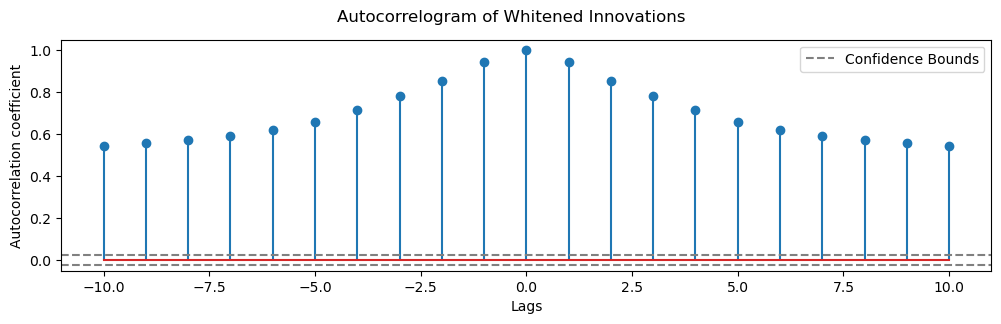

In [45]:
fig = result.plot_ensembles()
axes = fig.get_axes()
axes[0].set_title("Ensemble trajectories for the HBV model")
axes[0].set_ylabel("Snow")
axes[1].set_ylabel("Soil")
axes[2].set_ylabel("S_1")
axes[3].set_ylabel("S_2")
axes[4].set_ylabel("S_1 prev")
axes[4].set_xlabel("Time step")

fig = result.plot_observations()
ax = fig.get_axes()[0]
ax.set_title("Predicted discharge vs measured discharge")
ax.set_xlabel("Time step")
ax.set_ylabel("Runoff (mm/day)")
ax.set_ylim(bottom=0)

fig = result.plot_innovations()
ax = fig.get_axes()[0]
ax.set_xlabel("Time step")
ax.set_ylabel("Runoff residual")

fig = result.plot_whitened_innovations()
ax = fig.get_axes()[0]
ax.set_ylabel("Runoff residual")
ax.set_xlabel("Time step")

fig = result.plot_autocorrelogram()
ax = fig.get_axes()[0]
ax.set_ylabel("Autocorrelation coefficient")
ax.set_xlabel("Lags")